# Лабораторна робота №5. 
## Використання технологiї передачi знань для побудови моделi згорткових нейронних мереж в задачi класифiкацiї кольорових зображень.

#### Виконали:   
   
Варіант 2
- Сачек Владислава, КА-31
- Богданова Олександра, КА-32
- Плахтій Злата, КА-32
   
#### Хід виконання роботи:
1. Завантажити набiр кольорових зображень з попереднього практикуму згiдно з варiантом. Якщо набiр великого розмiру - можна обрати частину.
2. Пiдготувати данi для навчання. Виконати аугментацiю даних.
3. Роздiлити данi на навчальну, валiдацiйну i тестову пiдмножини.
4. Побудувати моделi класифiкацiї зображень на основi попередньо навчених глибоких згорткових мереж, використовуючи технологiю передачi знань (transfer learning):
- Завантажити попередньо навченi ваги. Iмпортувати ваги, отриманi пiд час навчання обраних глибоких моделей на наборi зображень ImageNet.
- Побудувати один або кiлька верхнiх повнозв’язних шарiв. Останнiм (результуючим) шаром мережi має бути повнозв’язний softmax-шар з кiлькiстю нейронiв, яка дорiвнює кiлькостi класiв в заданому за варiантом наборi даних.
- Заморозити попередньо навченi ваги. Заморожуючи змiннi попередньої моделi ми гарантуємо, що буде навчатися тiльки один (кiлька) верхнiх повнозв’язних шарiв; значення попередньої моделi залишаться незмiнними.
- Виконати донавчання доданих верхнiх шарiв на власному наборi зображень.
- Налаштувати параметри доданих верхнiх шарiв на валiдацiйнiй пiдмножинi.
Для дослiдження обрати кiлька попередньо навчених глибоких моделей, наприклад з наступних: VGG19, Xception, InceptionV3, ResNet152, DenseNet201, EfficientNetB7.
5. Вiдобразити у TensorBoard графiки, якi iлюструють оцiнки якостi навчання моделей:
- графiки змiни функцiї втрат на тренувальнiй i валiдацiйнiй множинах по мiрi навчання моделей,
- графiки змiни показникiв якостi моделi (accuracy, f1-score, AUC) на тренувальнiй i валiдацiйнiй множинах по мiрi навчання моделей.
6. Розрахувати на тестовiй множинi оцiнки якостi обраної найкращої моделi.
7. Завантажити зображення тестової множини i розпiзнати його навченими моделями.
8. Зробити висновки щодо якостi класифiкацiї на основi побудованих моделей. Порiвняти з результатами попереднього практикуму.

**Набір даних:** Rice Image Dataset (кольорові зображення)

### Імпорт бібліотек

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint

### Конфігурація 

In [2]:
DATA_DIR = "./Rice_Image_Dataset"

IMG_SIZE = 96
BATCH_SIZE = 64
SEED = 42

EPOCHS = 8
LEARNING_RATE = 1e-3

# Зменшення розміру датасету до 1/3
DATASET_FRACTION = 1 / 3

# Директорії для TensorBoard та збережених моделей
LOGS_ROOT  = "./logs"
MODELS_DIR = "./models"
os.makedirs(LOGS_ROOT, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"IMG_SIZE = {IMG_SIZE}, BATCH_SIZE = {BATCH_SIZE}, EPOCHS = {EPOCHS}")

IMG_SIZE = 96, BATCH_SIZE = 64, EPOCHS = 8


### Завантаження набору кольорових зображень Rice Image Dataset

Набір містить 75 000 кольорових зображень зерен рису п'яти сортів **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, **Karacadag**.    
Нехай розділення: 
- **train (60%)** - навчальна множина
- **val (20%)** - перевірочна множина
- **test (20%)** - тестова множина

Завантаження виконуємо за допомогою tf.keras.utils.image_dataset_from_directory, що автоматично зчитує зображення з підпапок, формує one-hot мітки та групує дані в батчі. 

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.4,
    subset="training",
    seed=SEED,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.4,
    subset="validation",
    seed=SEED,
)

val_test_size = len(val_test_ds)
half = val_test_size // 2

val_ds  = val_test_ds.take(half)
test_ds = val_test_ds.skip(half)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Класи: {CLASS_NAMES}")
print(f"Кількість класів: {NUM_CLASSES}")
print(f"Train: {len(train_ds)} батчів, Val: {len(val_ds)}, Test: {len(test_ds)}")

Found 75000 files belonging to 5 classes.
Using 45000 files for training.
Found 75000 files belonging to 5 classes.
Using 30000 files for validation.
Класи: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів: 5
Train: 704 батчів, Val: 234, Test: 235


### Скорочення обсягу даних

Беремо 1/3 від кожної підмножини для зменшення часу навчання

In [5]:
train_ds = train_ds.take(int(len(train_ds) * DATASET_FRACTION))
val_ds   = val_ds.take(int(len(val_ds)   * DATASET_FRACTION))
test_ds  = test_ds.take(int(len(test_ds) * DATASET_FRACTION))

print(f"Після скорочення: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)} батчів")
print(f"Орієнтовно зображень: train≈{len(train_ds)*BATCH_SIZE}, "
      f"val≈{len(val_ds)*BATCH_SIZE}, test≈{len(test_ds)*BATCH_SIZE}")

Після скорочення: Train=234, Val=78, Test=78 батчів
Орієнтовно зображень: train≈14976, val≈4992, test≈4992


### Візуалізація прикладів зображень

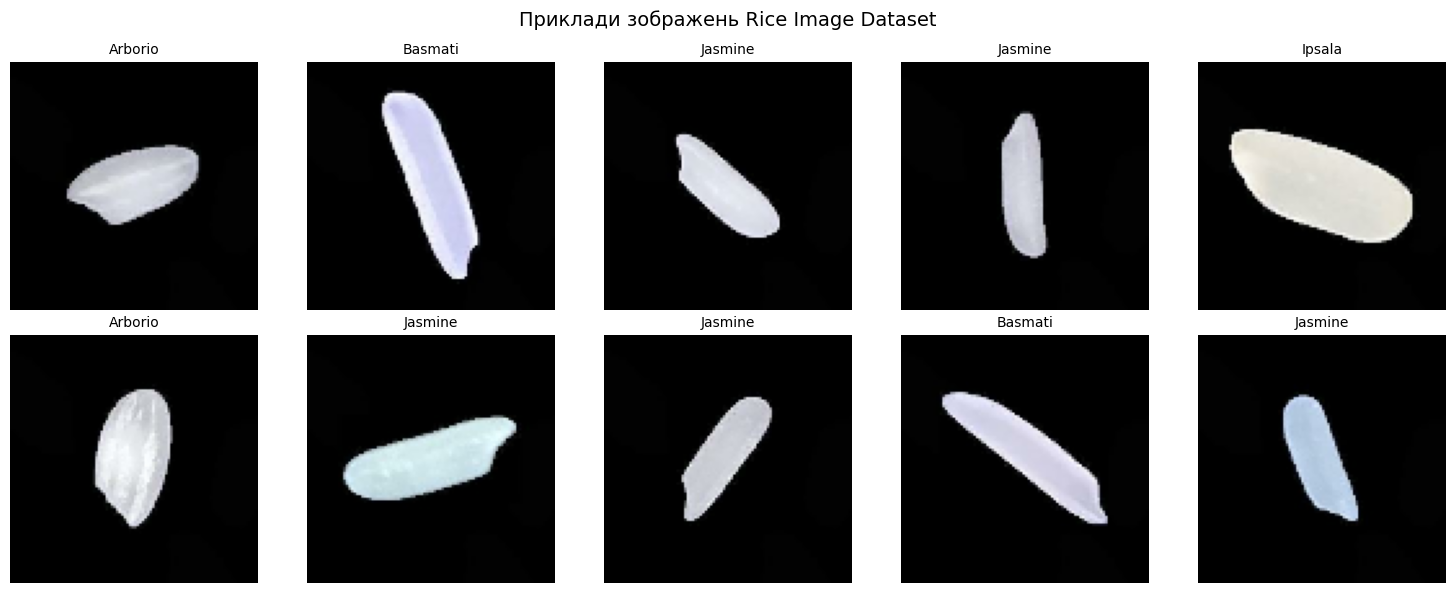

In [6]:
images, labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].numpy().astype("uint8"))
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("Приклади зображень Rice Image Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### Аугментація даних

Реалізуємо геометричні та фотометричні трансформації як `tf.keras.Sequential` зі спеціальних Random* шарів:

- `RandomFlip("horizontal")` — горизонтальне віддзеркалення (для зерна рису ця інваріантність природна).
- `RandomRotation(0.1)` — поворот у межах ±36 градусів.
- `RandomZoom(0.1)` — масштабування ±10%.
- `RandomContrast(0.1)` — варіація контрасту.

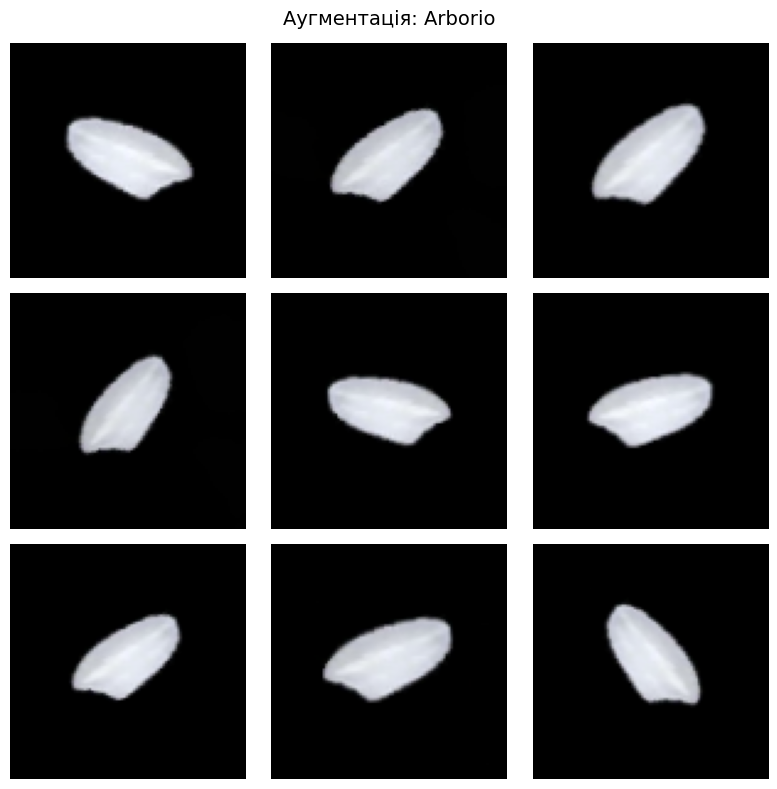

In [7]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

# Демонстрація: одне зображення прогнане через аугментацію 9 разів
sample = images[0:1]
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax in axes.flat:
    augmented = data_augmentation(sample, training=True)
    ax.imshow(augmented[0].numpy().astype("uint8"))
    ax.axis("off")
plt.suptitle(f"Аугментація: {CLASS_NAMES[np.argmax(labels[0])]}", fontsize=14)
plt.tight_layout()
plt.show()

### Оптимізація pipeline

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Структура логів та метрик

Для всіх наступних моделей використовуємо єдину структуру логів: `./logs/<model_name>/<timestamp>/`

**Метрики:**
- accuracy,
- AUC,
- F1Score(average='macro') — макроусереднений F1 score.

In [9]:
def make_callbacks(model_name: str, monitor: str = "val_loss"):
    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    log_dir   = os.path.join(LOGS_ROOT, model_name, timestamp)
    ckpt_path = os.path.join(MODELS_DIR, f"{model_name}_best.keras")

    callbacks = [
        TensorBoard(log_dir=log_dir, histogram_freq=1),
        EarlyStopping(monitor=monitor, patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, monitor=monitor,
                        save_best_only=True, verbose=1),
    ]
    return callbacks, log_dir


def get_metrics():
    return [
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc", multi_label=False),
        tf.keras.metrics.F1Score(average="macro", name="f1"),
    ]

### Модель Transfer Learning — VGG19

#### Опис моделі
VGG19 — глибока згорткова мережа з 19 шарами (16 згорткових + 3 повнозв'язних в оригіналі), розроблена Visual Geometry Group в Оксфорді у 2014 році. VGG19 використовує лише ядра 3×3 з stride=1 і padding='same' у всіх згорткових шарах та max-pooling 2×2 для зменшення розмірності. Послідовне збільшення кількості фільтрів у блоках між pooling-шарами дозволяє моделі накопичувати дедалі складніші ознаки — від країв і текстур до семантичних об'єктів. Модель має велику кількість параметрів — близько 143 млн в оригіналі (з повнозв'язними шарами), у нашій реалізації заморожено ~20 млн згорткової частини. Це робить мережу повільною для навчання, але ваги ImageNet виявляються універсальними для багатьох задач.

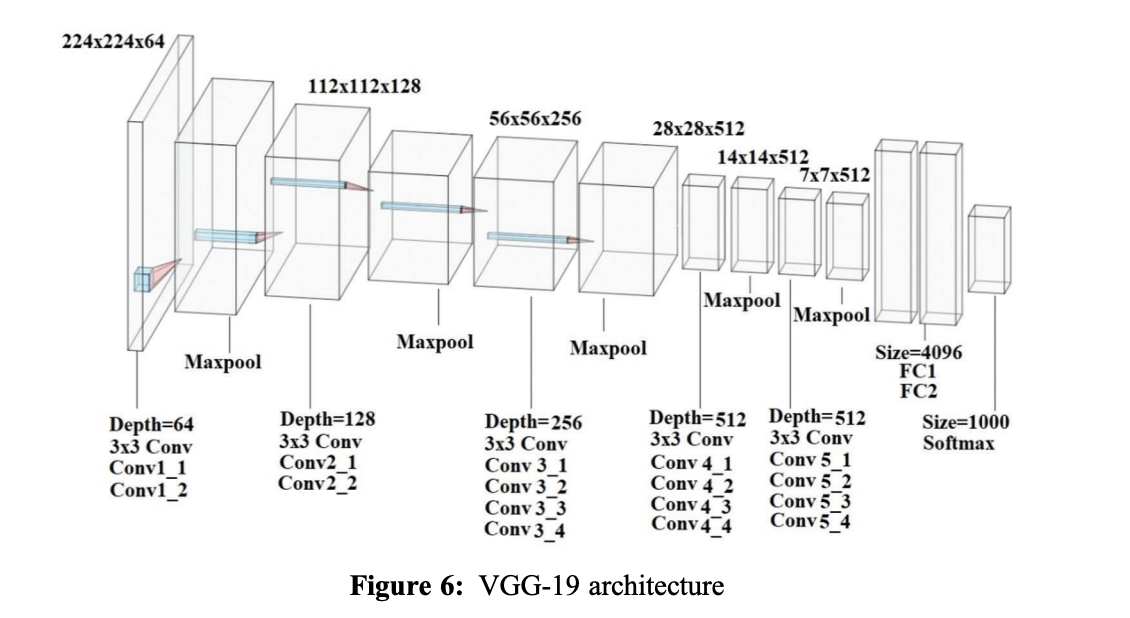

#### Архітектура

1. **Вхід** (96, 96, 3) — кольорове зображення 96×96 пікселів, значення в діапазоні [0, 255] без попередньої нормалізації.
2. `data_augmentation` — застосовує випадкові трансформації для штучного розширення тренувальної вибірки під час навчання.
3. `vgg19.preprocess_input` — переведення RGB->BGR і віднімання середніх ImageNet.
4. **VGG19 base** (frozen) — згорткова частина мережі з *include_top=False* і вагами ImageNet, заморожування *trainable=False* - гарантує, що під час донавчання змінюються лише ваги нової голови.
5. `GlobalAveragePooling2D` — усереднює feature maps по просторовому виміру, перетворюючи (3, 3, 512) на вектор (512,). На відміну від Flatten, не додає параметрів і менш схильний до перенавчання.
6. `Dense(256, relu)` + `Dropout(0.3)` — повнозв'язний шар, що навчається розпізнавати специфічні для рису ознаки, dropout вимикає 30% нейронів для регуляризації.
7. `Dense(NUM_CLASSES, softmax)` — вихідний шар із 5 нейронами (по одному на кожен сорт).

In [10]:
def build_vgg19_model(num_classes: int, img_size: int = IMG_SIZE):
    base = VGG19(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
    )
    base.trainable = False  # заморожуємо всі ваги попередньо навченої частини

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)            # (тільки під час training)
    x = vgg19_preprocess(x)                  # очікує [0, 255]
    x = base(x, training=False)              # forward pass через заморожену основу
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name="vgg19_transfer")
    return model, base


vgg19_model, vgg19_base = build_vgg19_model(NUM_CLASSES)
vgg19_model.summary()

frozen = sum(int(np.prod(w.shape)) for w in vgg19_base.weights)
trainable = sum(int(np.prod(w.shape)) for w in vgg19_model.trainable_weights)
print(f"\nЗаморожених параметрів VGG19: {frozen:,}")
print(f"Навчальних параметрів (тільки голова): {trainable:,}")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "vgg19_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 96, 96, 3) │          0 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 3, 3, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense (Dense)  │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ head_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 5)         │      1,285 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,156,997 (76.89 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)


Заморожених параметрів VGG19: 20,024,384
Навчальних параметрів (тільки голова): 132,613


#### Компіляція та навчання

In [11]:
vgg19_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=get_metrics(),
)

callbacks, vgg19_log_dir = make_callbacks("vgg19")
print(f"TensorBoard логи: {vgg19_log_dir}\n")

history_vgg19 = vgg19_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TensorBoard логи: ./logs/vgg19/20260510-180623

Epoch 1/8
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8067 - auc: 0.9385 - f1: 0.8064 - loss: 0.8404
Epoch 1: val_loss improved from None to 0.39819, saving model to ./models/vgg19_best.keras

Epoch 1: finished saving model to ./models/vgg19_best.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.9040 - auc: 0.9834 - f1: 0.9038 - loss: 0.3422 - val_accuracy: 0.8862 - val_auc: 0.9797 - val_f1: 0.8860 - val_loss: 0.3982
Epoch 2/8
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9680 - auc: 0.9971 - f1: 0.9680 - loss: 0.1043
Epoch 2: val_loss improved from 0.39819 to 0.19654, saving model to ./models/vgg19_best.keras

Epoch 2: finished saving model to ./models/vgg19_best.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9664 - auc: 0.9972 - f1: 0.9663 - loss: 0.1035 - val_accuracy: 0.9353 - val_auc: 0.9934 - val_f1: 0.9354 - val_loss: 0.1965
Epoch 3/8
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0

#### Графіки навчання

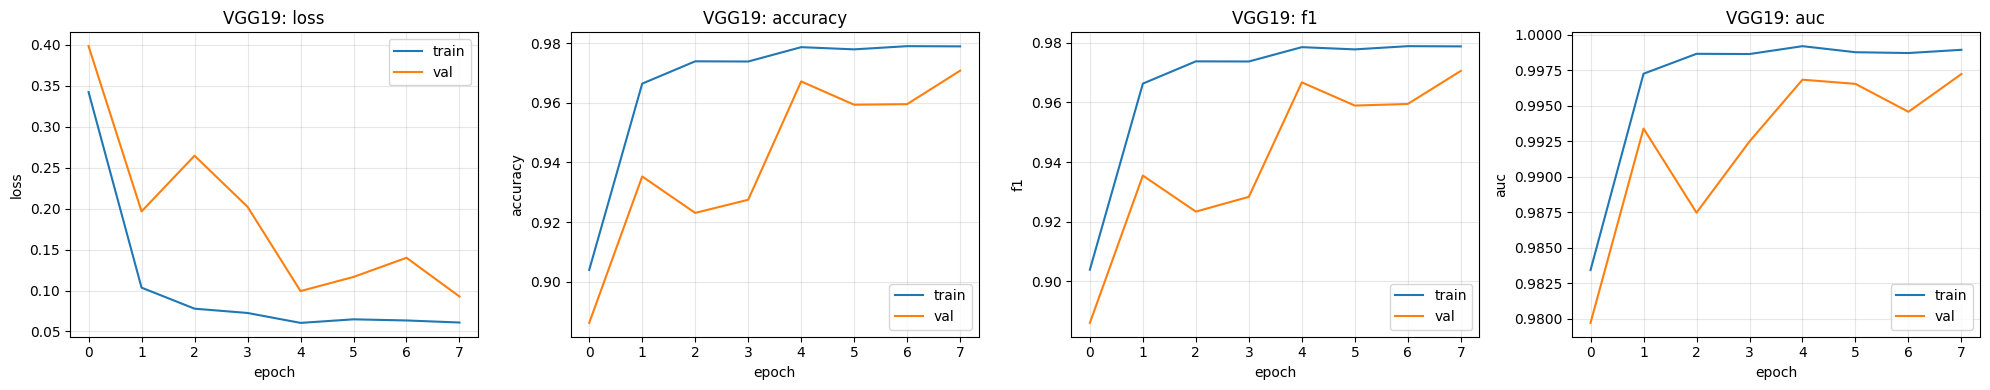

In [12]:
def plot_history(history, model_name: str):
    metrics_to_plot = ["loss", "accuracy", "f1", "auc"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, m in zip(axes, metrics_to_plot):
        if m in history.history:
            ax.plot(history.history[m], label=f"train")
            ax.plot(history.history[f"val_{m}"], label=f"val")
            ax.set_title(f"{model_name}: {m}")
            ax.set_xlabel("epoch")
            ax.set_ylabel(m)
            ax.legend()
            ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_history(history_vgg19, "VGG19")

#### Оцінка на тестовій множині

In [13]:
results = vgg19_model.evaluate(test_ds, verbose=0, return_dict=True)
print("VGG19 на тестовій множині:")
for name, value in results.items():
    print(f"  {name:>10s}: {value:.4f}")

VGG19 на тестовій множині:
    accuracy: 0.9728
         auc: 0.9975
          f1: 0.9729
        loss: 0.0883


#### Приклади передбачень

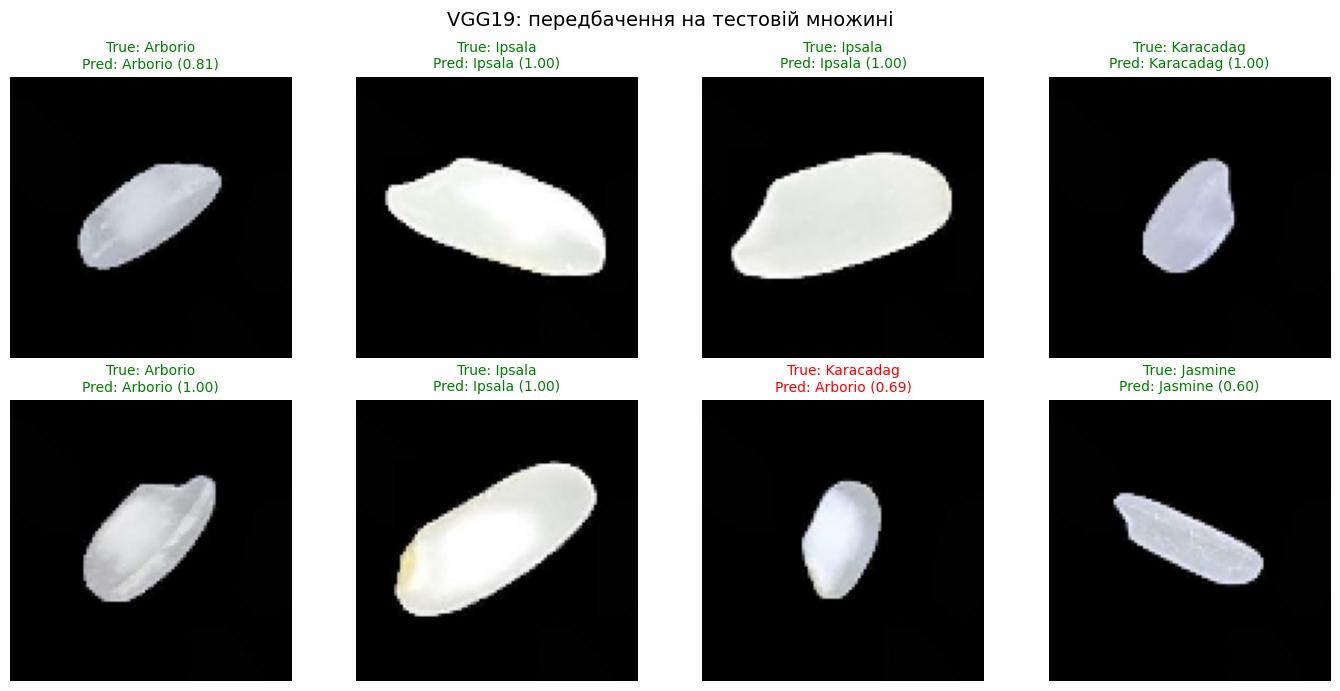

In [14]:
# один батч з тестової множини
test_images, test_labels = next(iter(test_ds))
preds = vgg19_model.predict(test_images[:8], verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i].numpy().astype("uint8"))
    pred_class = CLASS_NAMES[np.argmax(preds[i])]
    true_class = CLASS_NAMES[np.argmax(test_labels[i])]
    confidence = preds[i].max()
    color = "green" if pred_class == true_class else "red"
    ax.set_title(
        f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})",
        color=color, fontsize=10,
    )
    ax.axis("off")
plt.suptitle("VGG19: передбачення на тестовій множині", fontsize=14)
plt.tight_layout()
plt.show()

#### Аналіз отриманих результатів VGG19
   
Модель VGG19 з замороженою згортковою основою та новою повнозв'язною головою показала високу якість класифікації сортів рису: на тестовій множині досягнуто accuracy = ~0.97, F1 = ~0.97 та AUC = ~0.998, що практично збігається з валідаційними метриками останньої епохи. Це свідчить про хорошу узагальнюючу здатність моделі та відсутність суттєвого перенавчання. Вже після першої епохи модель досягла val_accuracy ~0.89, а основний приріст якості завершився до 5-ї епохи, після чого метрики вийшли на плато.
   
На епохах 2-4 бачимо нестабільність валідаційних кривих (val_loss зростає, accuracy просідає), тоді як тренувальні метрики весь час монотонно покращувались. Така поведінка типова для transfer learning із замороженою основою та невеликою головою: модель чутлива до конкретних батчів аугментованих даних. Механізм earlystopping із restore_best_weights=True коректно відпрацював — найкраща за val_loss модель збереглася на 8-й епосі, і саме її ваги використано для фінальної оцінки. 
   
Базова CNN з одним згортковим шаром з попереднього практикуму вже досягла вищої accuracy, ніж VGG19. Це можна пояснити тим, що ваги VGG19 з ImageNet оптимізовані для розпізнавання тисячі категорій реальних об'єктів, а зерна рису — це майже однорідні витягнуті форми на чорному тлі, де класифікація залежить від тонких відмінностей у формі, розмірі та текстурі, а не від високорівневих семантичних ознак. ImageNet-фільтри VGG19 виявились надлишково складними для цієї задачі, тоді як проста CNN з достатньою кількістю параметрів вирішує її майже ідеально. 
   
Для покращення результатів VGG19 можна використати fine-tuning: наприклад, після початкового навчання голови (5–8 епох) розморозити останній блок VGG19 (block5) і донавчити його з дуже малим learning rate, що дозволить високорівневим ознакам адаптуватись від ImageNet (загальні об'єкти) до специфіки рису (текстура зерен). Також можна використати сильнішу голову та регуляризацію; learning rate scheduling для зменшення learning rate, коли loss виходить на плато; збільшити IMG_SIZE або обсяг даних, проте це би потягнуло за собою значне збільшення часу навчання.